In [3]:
# --- 0. 필요한 라이브러리 및 클래스 정의 ---
import pandas as pd
import re
import os
import joblib
from typing import List
from kiwipiepy import Kiwi

class KiwiTokenizer:

    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되"]

    def __call__(self, text: str) -> List[str]:
        if self.kiwi is None:
            self.kiwi = Kiwi()
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens

    def __getstate__(self):
        # 저장 시 호출: kiwi 객체는 저장하지 않음
        state = self.__dict__.copy()
        if "kiwi" in state:
            del state["kiwi"]
        return state

    def __setstate__(self, state):
        # 로드 시 호출: kiwi 객체를 None으로 초기화
        self.__dict__.update(state)
        self.kiwi = None


print("초기 설정 및 필수 클래스 정의 완료.")

초기 설정 및 필수 클래스 정의 완료.


# 로지스틱 회귀 K-Fold

In [4]:
# --- 0. 필요한 라이브러리 및 클래스 정의 ---
import pandas as pd
import re
import os
import joblib
from typing import List
from kiwipiepy import Kiwi
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 윈도우 환경에서 한글 폰트가 깨지지 않도록 설정
plt.rcParams["font.family"] = "Malgun Gothic"
# 마이너스 기호가 깨지는 문제 해결
plt.rcParams["axes.unicode_minus"] = False


class KiwiTokenizer:

    def __init__(self):
        self.kiwi = None
        self.stop_words = ["하", "있", "되"]

    def __call__(self, text: str) -> List[str]:
        # 각 프로세스에서 최초 호출 시 Kiwi 객체를 한 번만 생성
        if self.kiwi is None:
            self.kiwi = Kiwi()
            self.kiwi.add_user_word("대포통장", "NNP")
            self.kiwi.add_user_word("계좌번호", "NNP")

        # 텍스트 정제
        cleaned_text = re.sub(r"[^\w\s<>]", " ", text)
        cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

        # 형태소 분석 및 필터링
        tokens = self.kiwi.tokenize(cleaned_text)
        result_tokens = [
            token.form
            for token in tokens
            if token.tag in ["NNG", "NNP", "VV", "VA", "XR"]
            and token.form not in self.stop_words
        ]
        return result_tokens

    def __getstate__(self):
        # 저장 시 호출: kiwi 객체는 저장하지 않음
        state = self.__dict__.copy()
        if "kiwi" in state:
            del state["kiwi"]
        return state

    def __setstate__(self, state):
        # 로드 시 호출: kiwi 객체를 None으로 초기화
        self.__dict__.update(state)
        self.kiwi = None


print("초기 설정 및 최종 클래스 정의 완료.")

초기 설정 및 최종 클래스 정의 완료.


In [5]:
# --- 1. 파일 경로 및 모델/Vectorizer 로딩 ---
print("저장된 Vectorizer와 Logistic Regression 모델을 불러옵니다...")

# Vectorizer 파일 경로
vectorizer_path = os.path.join("tfidf_vectorizer_6000_JJ.pkl")
# 로지스틱 회귀 모델 파일 경로
lr_model_path = os.path.join("models", "logistic_regression_model_6000_JJ.pkl")

try:
    loaded_vectorizer = joblib.load(vectorizer_path)
    loaded_lr_model = joblib.load(lr_model_path)
    print(f"Vectorizer 로드 완료: {vectorizer_path}")
    print(f"Logistic Regression 모델 로드 완료: {lr_model_path}")

except Exception as e:
    print(f"파일 로딩 중 에러 발생: {e}")

저장된 Vectorizer와 Logistic Regression 모델을 불러옵니다...
파일 로딩 중 에러 발생: Can't get attribute 'my_kiwi_tokenizer' on <module '__main__'>


시각화를 위한 한글 폰트 설정이 완료되었습니다.

--- 1. 모델 및 테스트 데이터 로드 ---
모델 로드 성공: C:\Users\user\Downloads\woogawooga\woogawooga_project\models\logistic2_v1.pkl
테스트 데이터 로드 성공: C:\Users\user\Downloads\woogawooga\woogawooga_project\dataset\시나리오테스트셋_60.csv (크기: (60, 3))

--- 2. 테스트 데이터 전처리 (Kiwi 토크나이저 적용) ---


C:\Users\user\AppData\Local\Temp\ipykernel_20416\2058642448.py:102: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test["text"].fillna("", inplace=True)


전처리 완료.

--- 3. 예측 수행 ---
예측 완료.

--- 4. 최종 성능 평가 결과 ---

[개별 성능 지표]
정확도 (Accuracy)  : 0.8500
정밀도 (Precision) : 0.7692
재현율 (Recall)    : 1.0000
F1-Score         : 0.8696

[종합 리포트]
              precision    recall  f1-score   support

    정상대화 (0)       1.00      0.70      0.82        30
   보이스피싱 (1)       0.77      1.00      0.87        30

    accuracy                           0.85        60
   macro avg       0.88      0.85      0.85        60
weighted avg       0.88      0.85      0.85        60


--- 5. 혼동 행렬 시각화 ---


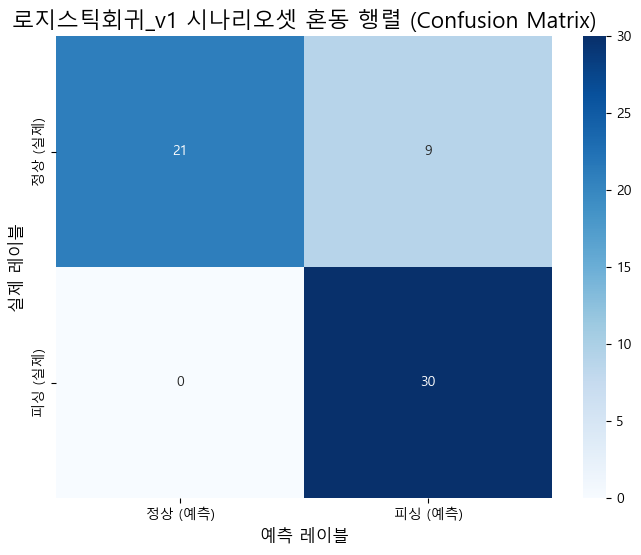

시각화가 완료되었습니다. 플롯 창을 확인해 주세요.


In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
from kiwipiepy import Kiwi
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# ==============================================================================
# 1. 사용자 설정 영역
# ==============================================================================
# 여기에 저장된 모델 파일의 전체 경로를 정확하게 입력해 주세요.
MODEL_PATH = (
    r"C:\Users\user\Downloads\woogawooga\woogawooga_project\models\stacking_v2.pkl"
)

# 평가에 사용할 테스트 데이터셋 파일의 경로를 입력해 주세요.
TEST_DATA_PATH = r"C:\Users\user\Downloads\woogawooga\woogawooga_project\dataset\시나리오테스트셋_60.csv"


# ==============================================================================
# 2. 시각화 한글 폰트 설정 (깨짐 방지)
# ==============================================================================
def set_korean_font():
    try:
        # Windows, Colab, Kaggle 등 환경에 맞는 폰트 자동 선택
        plt.rc("font", family="Malgun Gothic")  # Windows
    except:
        try:
            plt.rc("font", family="NanumGothic")  # Colab
        except:
            print(
                "한글 폰트를 찾을 수 없습니다. 시각화 결과에서 한글이 깨질 수 있습니다."
                "나눔고딕 또는 맑은 고딕 폰트를 설치해 주세요."
            )
    # 마이너스 부호 깨짐 방지
    plt.rc("axes", unicode_minus=False)
    print("시각화를 위한 한글 폰트 설정이 완료되었습니다.")


# ==============================================================================
# 3. 데이터 전처리 함수 (학습 스크립트와 반드시 동일해야 함)
# ==============================================================================
kiwi = Kiwi()


def tokenize_and_filter(text):
    """키위 기반 형태소 분석 및 필터링 (학습 때 사용한 함수와 동일)"""
    # 텍스트가 비어있거나 NaN 값일 경우 빈 문자열 반환
    if not isinstance(text, str) or text.strip() == "":
        return ""

    result = kiwi.analyze(text)[0][0]
    tokens = []
    for word, pos, _, _ in result:
        if pos in {"NNG", "NNP", "VV", "VA"}:  # 명사, 고유명사, 동사, 형용사만 선택
            if pos in {"VV", "VA"}:
                word = word + "다"  # 동사/형용사 표제어 처리
            tokens.append(word)
    return " ".join(tokens)


# ==============================================================================
# 4. 메인 평가 로직
# ==============================================================================
def evaluate_model(model_path, test_data_path):
    """학습된 모델을 로드하여 테스트셋으로 성능을 평가하고 시각화합니다."""

    # 폰트 설정
    set_korean_font()

    # --- 4.1 모델 및 데이터 로드 ---
    print("\n--- 1. 모델 및 테스트 데이터 로드 ---")
    try:
        # pkl 파일에서 학습된 파이프라인 모델을 불러옴
        loaded_model = joblib.load(model_path)
        print(f"모델 로드 성공: {model_path}")
    except FileNotFoundError:
        print(f"[오류] 모델 파일을 찾을 수 없습니다: {model_path}")
        return

    try:
        # 테스트 데이터셋 로드
        df_test = pd.read_csv(test_data_path, encoding="cp949")  # encoding='cp949'
        print(f"테스트 데이터 로드 성공: {test_data_path} (크기: {df_test.shape})")
    except FileNotFoundError:
        print(f"[오류] 테스트 데이터 파일을 찾을 수 없습니다: {test_data_path}")
        return

    # --- 4.2 테스트 데이터 전처리 ---
    print("\n--- 2. 테스트 데이터 전처리 (Kiwi 토크나이저 적용) ---")
    # 'text' 열의 결측값을 빈 문자열로 대체
    df_test["text"].fillna("", inplace=True)
    # 학습 때와 동일한 전처리 함수를 적용
    df_test["processed_text"] = df_test["text"].apply(tokenize_and_filter)

    X_test = df_test["processed_text"]
    y_test = df_test["is_phishing"]
    print("전처리 완료.")

    # --- 4.3 예측 수행 ---
    print("\n--- 3. 예측 수행 ---")
    # 로드한 모델을 사용해 테스트 데이터의 클래스를 예측
    y_pred = loaded_model.predict(X_test)
    print("예측 완료.")

    # --- 4.4 성능 평가 및 출력 ---
    print("\n--- 4. 최종 성능 평가 결과 ---")

    # 개별 성능 지표 계산
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n[개별 성능 지표]")
    print(f"정확도 (Accuracy)  : {accuracy:.4f}")
    print(f"정밀도 (Precision) : {precision:.4f}")
    print(f"재현율 (Recall)    : {recall:.4f}")
    print(f"F1-Score         : {f1:.4f}")

    print("\n[종합 리포트]")
    # classification_report를 사용해 종합 리포트 출력
    report = classification_report(
        y_test, y_pred, target_names=["정상대화 (0)", "보이스피싱 (1)"]
    )
    print(report)

    # --- 4.5 혼동 행렬(Confusion Matrix) 시각화 ---
    print("\n--- 5. 혼동 행렬 시각화 ---")
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",  # 정수 형태로 표기
        cmap="Blues",
        xticklabels=["정상 (예측)", "피싱 (예측)"],
        yticklabels=["정상 (실제)", "피싱 (실제)"],
    )
    plt.title("스태킹_v2 시나리오셋 혼동 행렬 (Confusion Matrix)", fontsize=16)
    plt.xlabel("예측 레이블", fontsize=12)
    plt.ylabel("실제 레이블", fontsize=12)
    plt.show()
    print("시각화가 완료되었습니다. 플롯 창을 확인해 주세요.")


if __name__ == "__main__":
    # 메인 함수 실행
    evaluate_model(MODEL_PATH, TEST_DATA_PATH)

폰트 설정: Malgun Gothic

--- 1. 모델 및 테스트 데이터 로드 ---
모델 로드 성공: C:\Users\user\Downloads\woogawooga\woogawooga_project\models\stacking_v2.pkl
테스트 데이터 로드 성공: C:\Users\user\Downloads\woogawooga\woogawooga_project\dataset\시나리오테스트셋_60.csv (크기: (60, 3))

--- 2. 테스트 데이터 전처리 (Kiwi 토크나이저 적용) ---


C:\Users\user\AppData\Local\Temp\ipykernel_5940\2216054657.py:119: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test["text"].fillna("", inplace=True)


전처리 완료.

--- 3. 예측 수행 ---
예측 완료.

--- 4. 최종 성능 평가 결과 ---

[개별 성능 지표]
정확도 (Accuracy)  : 0.8167
정밀도 (Precision) : 0.7317
재현율 (Recall)    : 1.0000
F1-Score         : 0.8451

[종합 리포트]
              precision    recall  f1-score   support

    정상대화 (0)       1.00      0.63      0.78        30
   보이스피싱 (1)       0.73      1.00      0.85        30

    accuracy                           0.82        60
   macro avg       0.87      0.82      0.81        60
weighted avg       0.87      0.82      0.81        60


--- 5. 예측 오류 분석 및 저장 ---
총 11개의 예측 오류 데이터를 'incorrect_predictions.csv' 파일로 저장했습니다.

[오류 데이터 샘플 (상위 5개)]
    is_phishing  predicted_label  \
0             0                1   
2             0                1   
5             0                1   
20            0                1   
22            0                1   

                                                 text  
0   네  여보세요. 네  안녕하세요. 국민은행 상담센터입니다. 무엇을 도와드릴까요? 안...  
2   엄마  나 또 액정이 깨졌어  지금 친구 폰으로 전화했어. 더 깨졌어  핸드폰을 얼...  
5  

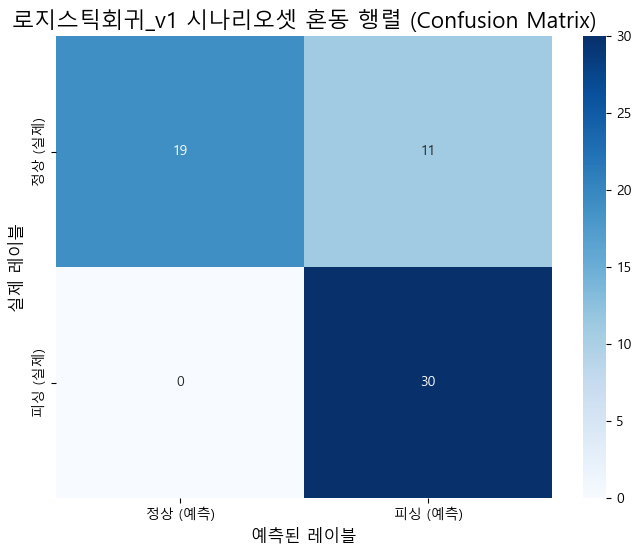

In [1]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
from kiwipiepy import Kiwi
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# ==============================================================================
# 1. 사용자 설정 영역
# ==============================================================================
# 여기에 저장된 모델 파일의 전체 경로를 정확하게 입력해 주세요.
# ★★★ 경로 설정이 올바른지 다시 한번 확인해 주세요! ★★★
MODEL_PATH = (
    r"C:\Users\user\Downloads\woogawooga\woogawooga_project\models\stacking_v2.pkl"
)

# 평가에 사용할 테스트 데이터셋 파일의 경로를 입력해 주세요.
# ★★★ 경로 설정이 올바른지 다시 한번 확인해 주세요! ★★★
TEST_DATA_PATH = r"C:\Users\user\Downloads\woogawooga\woogawooga_project\dataset\시나리오테스트셋_60.csv"

# 예측이 틀린 결과를 저장할 파일 이름
INCORRECT_PRED_PATH = "incorrect_predictions.csv"


# ==============================================================================
# 2. 시각화 한글 폰트 설정 (깨짐 방지)
# ==============================================================================
def set_korean_font():
    """운영체제에 맞는 한글 폰트를 설정합니다."""
    try:
        plt.rc("font", family="Malgun Gothic")  # Windows
        print("폰트 설정: Malgun Gothic")
    except:
        try:
            plt.rc("font", family="AppleGothic")  # MacOS
            print("폰트 설정: AppleGothic")
        except:
            try:
                plt.rc("font", family="NanumGothic")  # Linux, Colab
                print("폰트 설정: NanumGothic")
            except:
                print(
                    "[경고] 한글 폰트를 찾을 수 없습니다. 시각화 시 한글이 깨질 수 있습니다."
                )
    # 마이너스 부호 깨짐 방지
    plt.rc("axes", unicode_minus=False)


# ==============================================================================
# 3. 데이터 전처리 함수 (학습 스크립트와 반드시 동일해야 함)
# ==============================================================================
kiwi = Kiwi()


def tokenize_and_filter(text):
    """Kiwi 형태소 분석기를 사용하여 텍스트를 토큰화하고 필터링합니다."""
    if not isinstance(text, str) or text.strip() == "":
        return ""

    # Kiwi를 사용한 형태소 분석
    result = kiwi.analyze(text)[0][0]
    tokens = []
    # 지정된 품사(명사, 동사, 형용사)만 추출
    for word, pos, _, _ in result:
        if pos in {"NNG", "NNP", "VV", "VA"}:
            if pos in {"VV", "VA"}:
                word += "다"  # 용언의 기본형으로 변환
            tokens.append(word)
    return " ".join(tokens)


# ==============================================================================
# 4. 메인 평가 로직
# ==============================================================================
def evaluate_model(model_path, test_data_path):
    """모델을 로드하여 성능을 평가하고, 오류 분석 결과를 저장합니다."""

    set_korean_font()

    # --- 4.1 모델 및 데이터 로드 ---
    print("\n--- 1. 모델 및 테스트 데이터 로드 ---")
    try:
        loaded_model = joblib.load(model_path)
        print(f"모델 로드 성공: {model_path}")
    except FileNotFoundError:
        print(f"[오류] 모델 파일을 찾을 수 없습니다: {model_path}")
        return
    except Exception as e:
        print(f"[오류] 모델 로드 중 예외가 발생했습니다: {e}")
        return

    try:
        # 'cp949' 인코딩으로 CSV 파일 로드
        df_test = pd.read_csv(test_data_path, encoding="cp949")
        print(f"테스트 데이터 로드 성공: {test_data_path} (크기: {df_test.shape})")
    except FileNotFoundError:
        print(f"[오류] 테스트 데이터 파일을 찾을 수 없습니다: {test_data_path}")
        return
    except Exception as e:
        print(f"[오류] 데이터 로드 중 예외가 발생했습니다: {e}")
        return

    # --- 4.2 테스트 데이터 전처리 ---
    print("\n--- 2. 테스트 데이터 전처리 (Kiwi 토크나이저 적용) ---")
    if "text" not in df_test.columns:
        print("[오류] 'text' 열을 데이터에서 찾을 수 없습니다.")
        return

    df_test["text"].fillna("", inplace=True)
    df_test["processed_text"] = df_test["text"].apply(tokenize_and_filter)

    X_test = df_test["processed_text"]
    y_test = df_test["is_phishing"]
    print("전처리 완료.")

    # --- 4.3 예측 수행 ---
    print("\n--- 3. 예측 수행 ---")
    y_pred = loaded_model.predict(X_test)
    print("예측 완료.")

    # --- 4.4 성능 평가 및 출력 ---
    print("\n--- 4. 최종 성능 평가 결과 ---")
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n[개별 성능 지표]")
    print(f"정확도 (Accuracy)  : {accuracy:.4f}")
    print(f"정밀도 (Precision) : {precision:.4f}")
    print(f"재현율 (Recall)    : {recall:.4f}")
    print(f"F1-Score         : {f1:.4f}")

    print("\n[종합 리포트]")
    report = classification_report(
        y_test, y_pred, target_names=["정상대화 (0)", "보이스피싱 (1)"]
    )
    print(report)

    # ==============================================================================
    # ★★★ 추가된 코드 시작 ★★★
    # --- 4.5 예측 오류 분석 및 CSV 저장 ---
    # ==============================================================================
    print(f"\n--- 5. 예측 오류 분석 및 저장 ---")
    # y_test(실제값)와 y_pred(예측값)가 다른 인덱스를 찾음
    incorrect_indices = y_test[y_test != y_pred].index

    if not incorrect_indices.empty:
        # 원본 데이터프레임에서 틀린 예측에 해당하는 행들을 추출
        df_incorrect = df_test.loc[incorrect_indices].copy()
        # 해당 행들의 예측된 레이블을 새로운 열로 추가
        df_incorrect["predicted_label"] = y_pred[incorrect_indices]

        try:
            # 오류 분석 결과를 CSV 파일로 저장 (Excel에서 한글 깨짐 방지 위해 'utf-8-sig' 인코딩 사용)
            df_incorrect.to_csv(INCORRECT_PRED_PATH, index=False, encoding="utf-8-sig")
            print(
                f"총 {len(df_incorrect)}개의 예측 오류 데이터를 '{INCORRECT_PRED_PATH}' 파일로 저장했습니다."
            )
            print("\n[오류 데이터 샘플 (상위 5개)]")
            # is_phishing(실제), predicted_label(예측), text(원본) 순서로 주요 열만 출력
            print(df_incorrect[["is_phishing", "predicted_label", "text"]].head())
        except Exception as e:
            print(
                f"[오류] 오류 분석 결과를 파일로 저장하는 중 예외가 발생했습니다: {e}"
            )
    else:
        print("모든 예측이 정확합니다! 저장할 오류 데이터가 없습니다.")
    # ==============================================================================
    # ★★★ 추가된 코드 종료 ★★★
    # ==============================================================================

    # --- 4.6 혼동 행렬(Confusion Matrix) 시각화 ---
    print("\n--- 6. 혼동 행렬 시각화 ---")
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["정상 (예측)", "피싱 (예측)"],
        yticklabels=["정상 (실제)", "피싱 (실제)"],
    )
    plt.title("로지스틱회귀_v1 시나리오셋 혼동 행렬 (Confusion Matrix)", fontsize=16)
    plt.xlabel("예측된 레이블", fontsize=12)
    plt.ylabel("실제 레이블", fontsize=12)
    # plt.show() # 로컬 환경에서 바로 확인하려면 주석 해제

    # 시각화 결과 파일 저장
    plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
    print("혼동 행렬 이미지를 'confusion_matrix.png' 파일로 저장했습니다.")


if __name__ == "__main__":
    # 메인 함수 실행
    evaluate_model(MODEL_PATH, TEST_DATA_PATH)